Feature Engineering

In [1]:
# -----------------------------------
# Cell 0: Imports 
# -----------------------------------

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from arch import arch_model
from itertools import permutations

In [2]:
# -----------------------------------
# Cell 1: Load Data & Compute Returns
# -----------------------------------

# Load VIX history (DATE, CLOSE)
df = pd.read_csv(
    r'C:\Users\npwol\OneDrive\Desktop\CVR (Classifying VIX Regimes)\VIX_History.csv',
    parse_dates=['DATE']
).set_index('DATE')

# Compute daily percent change as "returns"
df['RETURN'] = df['CLOSE'].pct_change() * 100
df.dropna(subset=['RETURN'], inplace=True)


In [3]:
# -----------------------------------
# Cell 2: Fit FIGARCH on VIX Returns
# -----------------------------------

# Fit FIGARCH(1,d,1) with Student-t errors on your RETURN series
fig_spec = dict(vol='FIGARCH', p=1, o=0, q=1, dist='StudentsT')
fig_model = arch_model(df['RETURN'], **fig_spec).fit(disp='off')

# Extract the in-sample conditional volatility series
df['FIGARCH_CV'] = fig_model.conditional_volatility

# Quick check
print("FIGARCH conditional vol head:")
print(df['FIGARCH_CV'].head())


FIGARCH conditional vol head:
DATE
1990-01-03    7.604284
1990-01-04    7.370682
1990-01-05    7.200691
1990-01-08    6.988308
1990-01-09    6.594171
Name: FIGARCH_CV, dtype: float64


In [4]:
# -----------------------------------
# Cell 3: Permutation Entropy Helper
# -----------------------------------

def permutation_entropy(ts, m=4, delay=1):
    """
    Compute the permutation entropy of a 1D array `ts` with embedding dim m and time lag delay.
    Returns NaN if the series is too short.
    """
    n = len(ts)
    if n < m * delay:
        return np.nan
    # all m! possible order patterns
    perms = np.array(list(permutations(range(m))))
    counts = np.zeros(len(perms))
    # count occurrences of each pattern
    for i in range(n - (m-1)*delay):
        window = ts[i : i + m*delay : delay]
        order = np.argsort(window)
        # find which permutation matches
        for idx, p in enumerate(perms):
            if np.array_equal(order, p):
                counts[idx] += 1
                break
    p = counts[counts>0] / counts[counts>0].sum()
    return -np.sum(p * np.log(p))

In [5]:
# -----------------------------------
# Cell 4: Permutation Entropy on Raw VIX Level
# -----------------------------------

# Compute PE on the *closing level* of VIX (not returns) over a 50-day window.
# We use m=4 (24 patterns) to keep the estimates stable and fast.
df['PE_vix'] = df['RETURN'] \
    .rolling(window=50, min_periods=20) \
    .apply(lambda x: permutation_entropy(x, m=4, delay=1), raw=False)

print("\nPermutation Entropy on raw VIX head:")
print(df['PE_vix'].dropna().head())



Permutation Entropy on raw VIX head:
DATE
1990-01-30    2.507026
1990-01-31    2.582306
1990-02-01    2.652588
1990-02-02    2.649159
1990-02-05    2.714452
Name: PE_vix, dtype: float64


In [6]:
# -----------------------------------
# Cell 5: Permutation Entropy on FIGARCH Volatility
# -----------------------------------

# Compute PE on the FIGARCH conditional-vol series over 30 days
df['PE_figarch_cv'] = df['FIGARCH_CV'] \
    .rolling(window=50, min_periods=20) \
    .apply(permutation_entropy, raw=False)

print("\nPermutation Entropy on FIGARCH vol head:")
print(df['PE_figarch_cv'].dropna().head())



Permutation Entropy on FIGARCH vol head:
DATE
1990-01-30    1.868863
1990-01-31    1.812143
1990-02-01    1.922959
1990-02-02    2.025326
1990-02-05    2.120326
Name: PE_figarch_cv, dtype: float64


In [7]:
# -----------------------------------
# Cell 6: Correlation Analysis
# -----------------------------------

corr_fig_pe_fig = df[['FIGARCH_CV','PE_figarch_cv']].dropna().corr().iloc[0,1]
print(f"Correlation of FIGARCH and Permutation Entropy of FIGARCH: {corr_fig_pe_fig}")

corr_fig_pe_vix = df[['FIGARCH_CV','PE_vix']].dropna().corr().iloc[0,1]
print(f"Correlation of FIGARCH and Permutation Entropy of VIX: {corr_fig_pe_vix}")


Correlation of FIGARCH and Permutation Entropy of FIGARCH: -0.09842768481231531
Correlation of FIGARCH and Permutation Entropy of VIX: -0.013043669450245987


In [8]:
# -----------------------------------
# Cell 7: Hurst Exponent Helper Function
# -----------------------------------

def hurst_exponent(series):
    """
    Compute the R/S Hurst exponent for a 1D numeric series.

    Steps:
    1) Mean-center the series and form the cumulative deviate Y.
    2) Compute range R = max(Y) – min(Y).
    3) Compute standard deviation S of the original series.
    4) Return H = log(R/S) / log(N), where N = len(series).

    Interpretation:
      H > 0.5 → persistent (trends tend to continue)
      H < 0.5 → anti-persistent (trends tend to reverse)
      H ≈ 0.5 → uncorrelated (random walk)

    Returns NaN if series is too short or S == 0.
    """
    N = len(series)
    if N < 20:
        return np.nan
    Y = np.cumsum(series - np.mean(series))
    R = np.max(Y) - np.min(Y)
    S = np.std(series, ddof=0)
    return np.log(R / S) / np.log(N) if S > 0 else np.nan


In [9]:
# -----------------------------------
# Cell 8: 50-Day Hurst on Raw VIX Level
# -----------------------------------
df['HE_vix_50'] = df['CLOSE'] \
    .rolling(window=50, min_periods=20) \
    .apply(hurst_exponent, raw=False)

print("50-Day Hurst Exponent on Raw VIX (head):")
print(df['HE_vix_50'].dropna().head())


50-Day Hurst Exponent on Raw VIX (head):
DATE
1990-01-30    0.706636
1990-01-31    0.708568
1990-02-01    0.709326
1990-02-02    0.708548
1990-02-05    0.708255
Name: HE_vix_50, dtype: float64


In [10]:
# -----------------------------------
# Cell 9: 50-Day Hurst on VIX RETURN
# -----------------------------------
df['HE_return_50'] = df['RETURN'] \
    .rolling(window=50, min_periods=20) \
    .apply(hurst_exponent, raw=False)

print("50-Day Hurst Exponent on VIX Return (head):")
print(df['HE_return_50'].dropna().head())

50-Day Hurst Exponent on VIX Return (head):
DATE
1990-01-30    0.388132
1990-01-31    0.395494
1990-02-01    0.414744
1990-02-02    0.431827
1990-02-05    0.436116
Name: HE_return_50, dtype: float64


In [11]:
# -----------------------------------
# Cell 10: 50-Day Hurst on FIGARCH Volatility
# -----------------------------------
df['HE_figarch_cv_50'] = df['FIGARCH_CV'] \
    .rolling(window=50, min_periods=20) \
    .apply(hurst_exponent, raw=False)

print("50-Day Hurst Exponent on FIGARCH Volatility (head):")
print(df['HE_figarch_cv_50'].dropna().head())


50-Day Hurst Exponent on FIGARCH Volatility (head):
DATE
1990-01-30    0.679497
1990-01-31    0.686974
1990-02-01    0.692452
1990-02-02    0.697292
1990-02-05    0.701051
Name: HE_figarch_cv_50, dtype: float64


In [12]:
# -----------------------------------
# Cell 11: 50-Day Hurst on PE of VIX Returns
# -----------------------------------
df['HE_pe_vix_50'] = df['PE_vix'] \
    .rolling(window=50, min_periods=20) \
    .apply(hurst_exponent, raw=False)

print("50-Day Hurst Exponent on PE of VIX Returns (head):")
print(df['HE_pe_vix_50'].dropna().head())


50-Day Hurst Exponent on PE of VIX Returns (head):
DATE
1990-02-27    0.597860
1990-02-28    0.605347
1990-03-01    0.611744
1990-03-02    0.616678
1990-03-05    0.621967
Name: HE_pe_vix_50, dtype: float64


In [13]:
# -----------------------------------
# Cell 12: 50-Day Hurst on PE of FIGARCH Volatility
# -----------------------------------
df['HE_pe_figarch_cv_50'] = df['PE_figarch_cv'] \
    .rolling(window=50, min_periods=20) \
    .apply(hurst_exponent, raw=False)

print("50-Day Hurst Exponent on PE of FIGARCH Volatility (head):")
print(df['HE_pe_figarch_cv_50'].dropna().head())


50-Day Hurst Exponent on PE of FIGARCH Volatility (head):
DATE
1990-02-27    0.562171
1990-02-28    0.577440
1990-03-01    0.588432
1990-03-02    0.595524
1990-03-05    0.598832
Name: HE_pe_figarch_cv_50, dtype: float64


In [14]:
# -----------------------------------
# Cell 13: Save CSV
# -----------------------------------

# 1) Select and rename the export columns
export_cols = [
    'DATE',                # from index after reset
    'CLOSE', 
    'RETURN', 
    'FIGARCH_CV',          # FIGARCH conditional volatility
    'PE_vix',              # PE of VIX returns
    'PE_figarch_cv',       # PE of FIGARCH volatility
    'HE_vix_50',           # 50-day Hurst on VIX levels
    'HE_return_50',        # 50-day Hurst on VIX returns
    'HE_figarch_cv_50',    # 50-day Hurst on FIGARCH volatility
    'HE_pe_vix_50',        # 50-day Hurst on PE of VIX returns
    'HE_pe_figarch_cv_50'  # 50-day Hurst on PE of FIGARCH vol
]

# 2) Build the DataFrame and save
export_df = df.reset_index()[export_cols]
export_df.to_csv('VIX_Analysis_2.0.csv', index=False)

print(f"Saved {len(export_df)} rows with columns {export_cols} to 'vix_regime_features.csv'")


Saved 8889 rows with columns ['DATE', 'CLOSE', 'RETURN', 'FIGARCH_CV', 'PE_vix', 'PE_figarch_cv', 'HE_vix_50', 'HE_return_50', 'HE_figarch_cv_50', 'HE_pe_vix_50', 'HE_pe_figarch_cv_50'] to 'vix_regime_features.csv'


Visual Inspection

In [42]:
# -----------------------------------
# Cell 14: Load Features from CSV
# -----------------------------------

path = r'C:\Users\npwol\OneDrive\Desktop\CVR (Classifying VIX Regimes)\VIX_Analysis_2.0.csv'
df = pd.read_csv(path, parse_dates=['DATE']).set_index('DATE')

# List of features for our visuals
features = [
    'CLOSE', 
    'RETURN', 
    'FIGARCH_CV',          # FIGARCH conditional volatility
    'PE_vix',              # PE of VIX returns
    'PE_figarch_cv',       # PE of FIGARCH volatility
    'HE_vix_50',           # 50-day Hurst on VIX levels
    'HE_return_50',        # 50-day Hurst on VIX returns
    'HE_figarch_cv_50',    # 50-day Hurst on FIGARCH volatility
    'HE_pe_vix_50',        # 50-day Hurst on PE of VIX returns
    'HE_pe_figarch_cv_50'  # 50-day Hurst on PE of FIGARCH vol
]


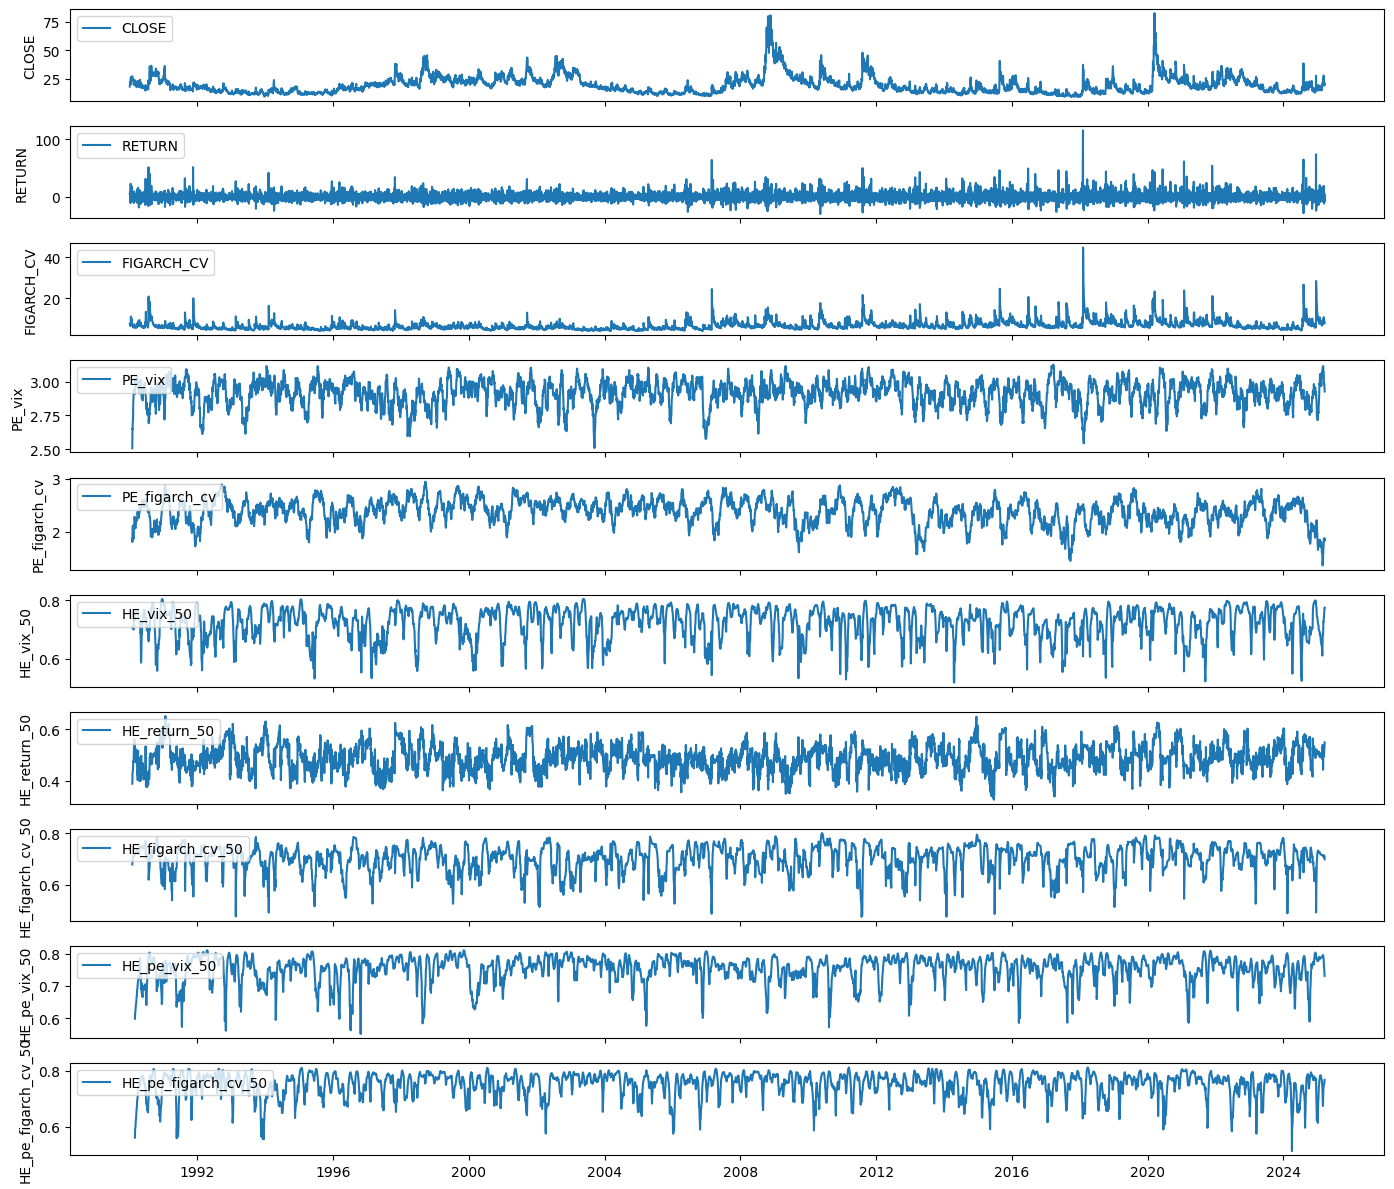

In [43]:
# -----------------------------------
# Cell 15: Overlaid Time‐Series Panels
# -----------------------------------

fig, axs = plt.subplots(len(features), 1, figsize=(14, 12), sharex=True)
for ax, col in zip(axs, features):
    ax.plot(df.index, df[col], label=col)
    ax.set_ylabel(col)
    ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


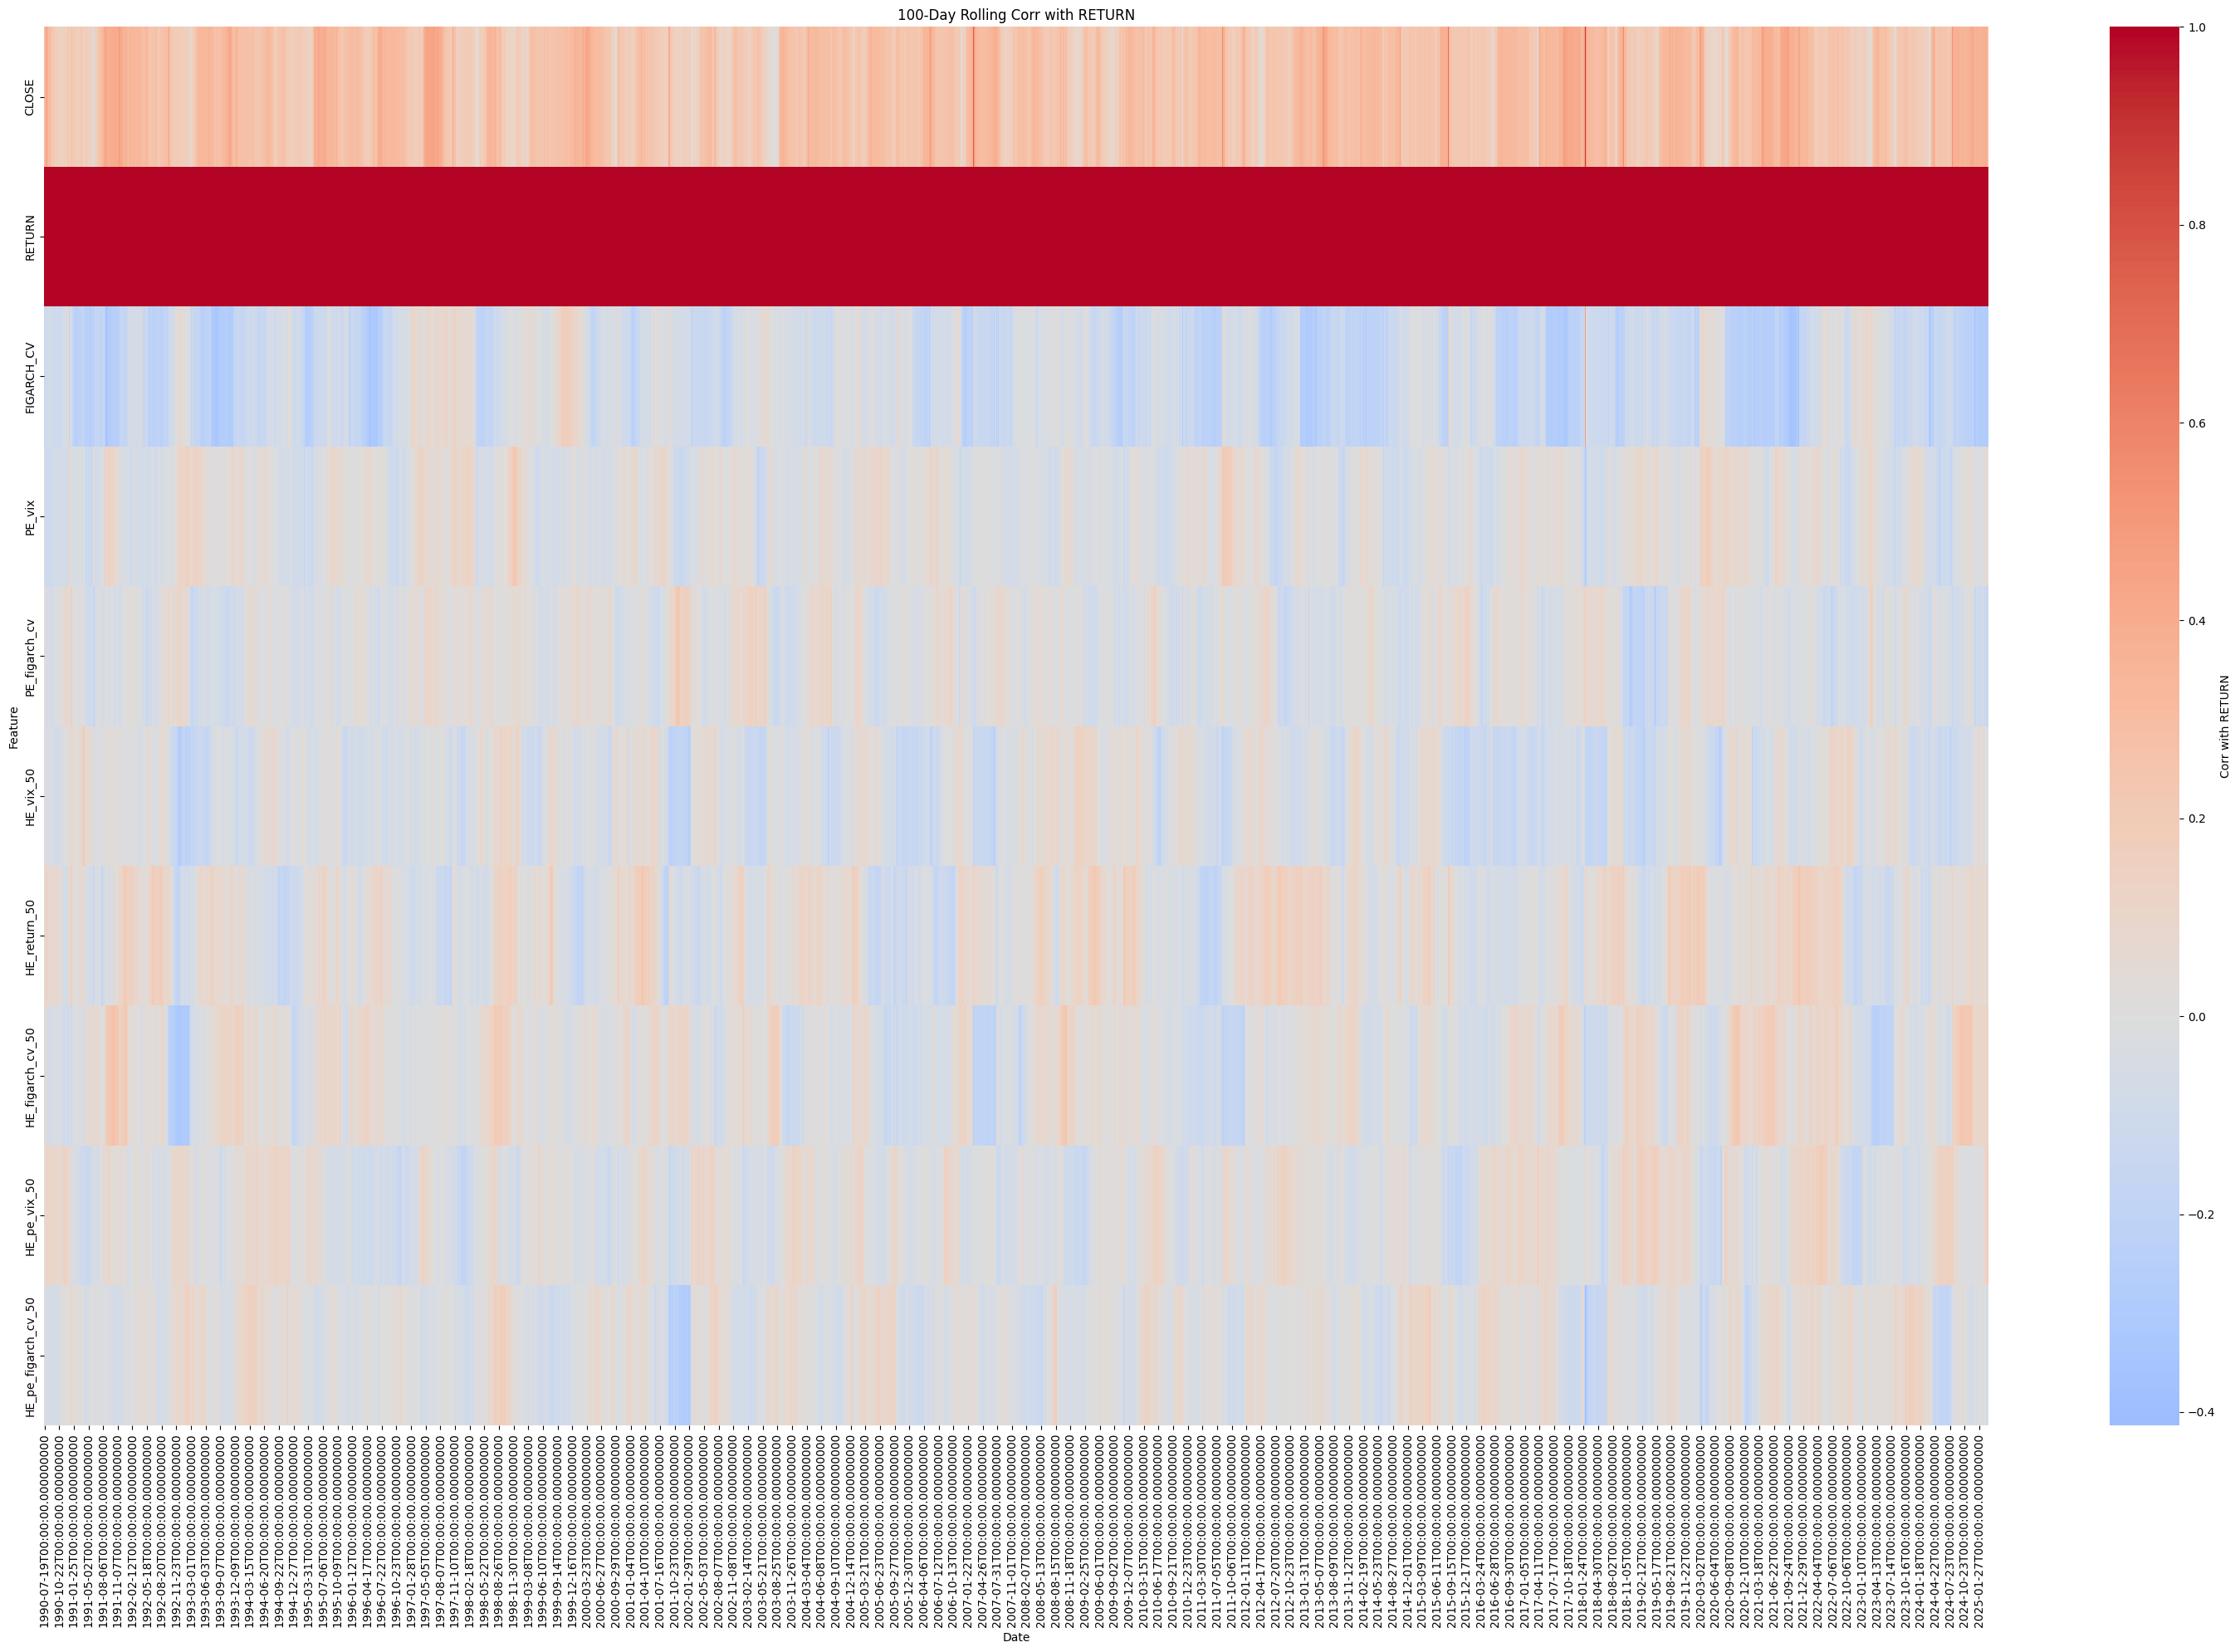

In [17]:
# -----------------------------------
# Cell 16: 100-Day Rolling Correlation Heatmap
# -----------------------------------

window = 100
rolling_corr = df[features].rolling(window).corr().dropna()
# extract correlations of every feature with FIGARCH_CV
corr_vs_return = rolling_corr.xs('RETURN', level=1)

plt.figure(figsize=(30, 20))
sns.heatmap(corr_vs_return.T, cmap='coolwarm', center=0, cbar_kws={'label':'Corr with RETURN'})
plt.title(f'{window}-Day Rolling Corr with RETURN')
plt.xlabel('Date')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


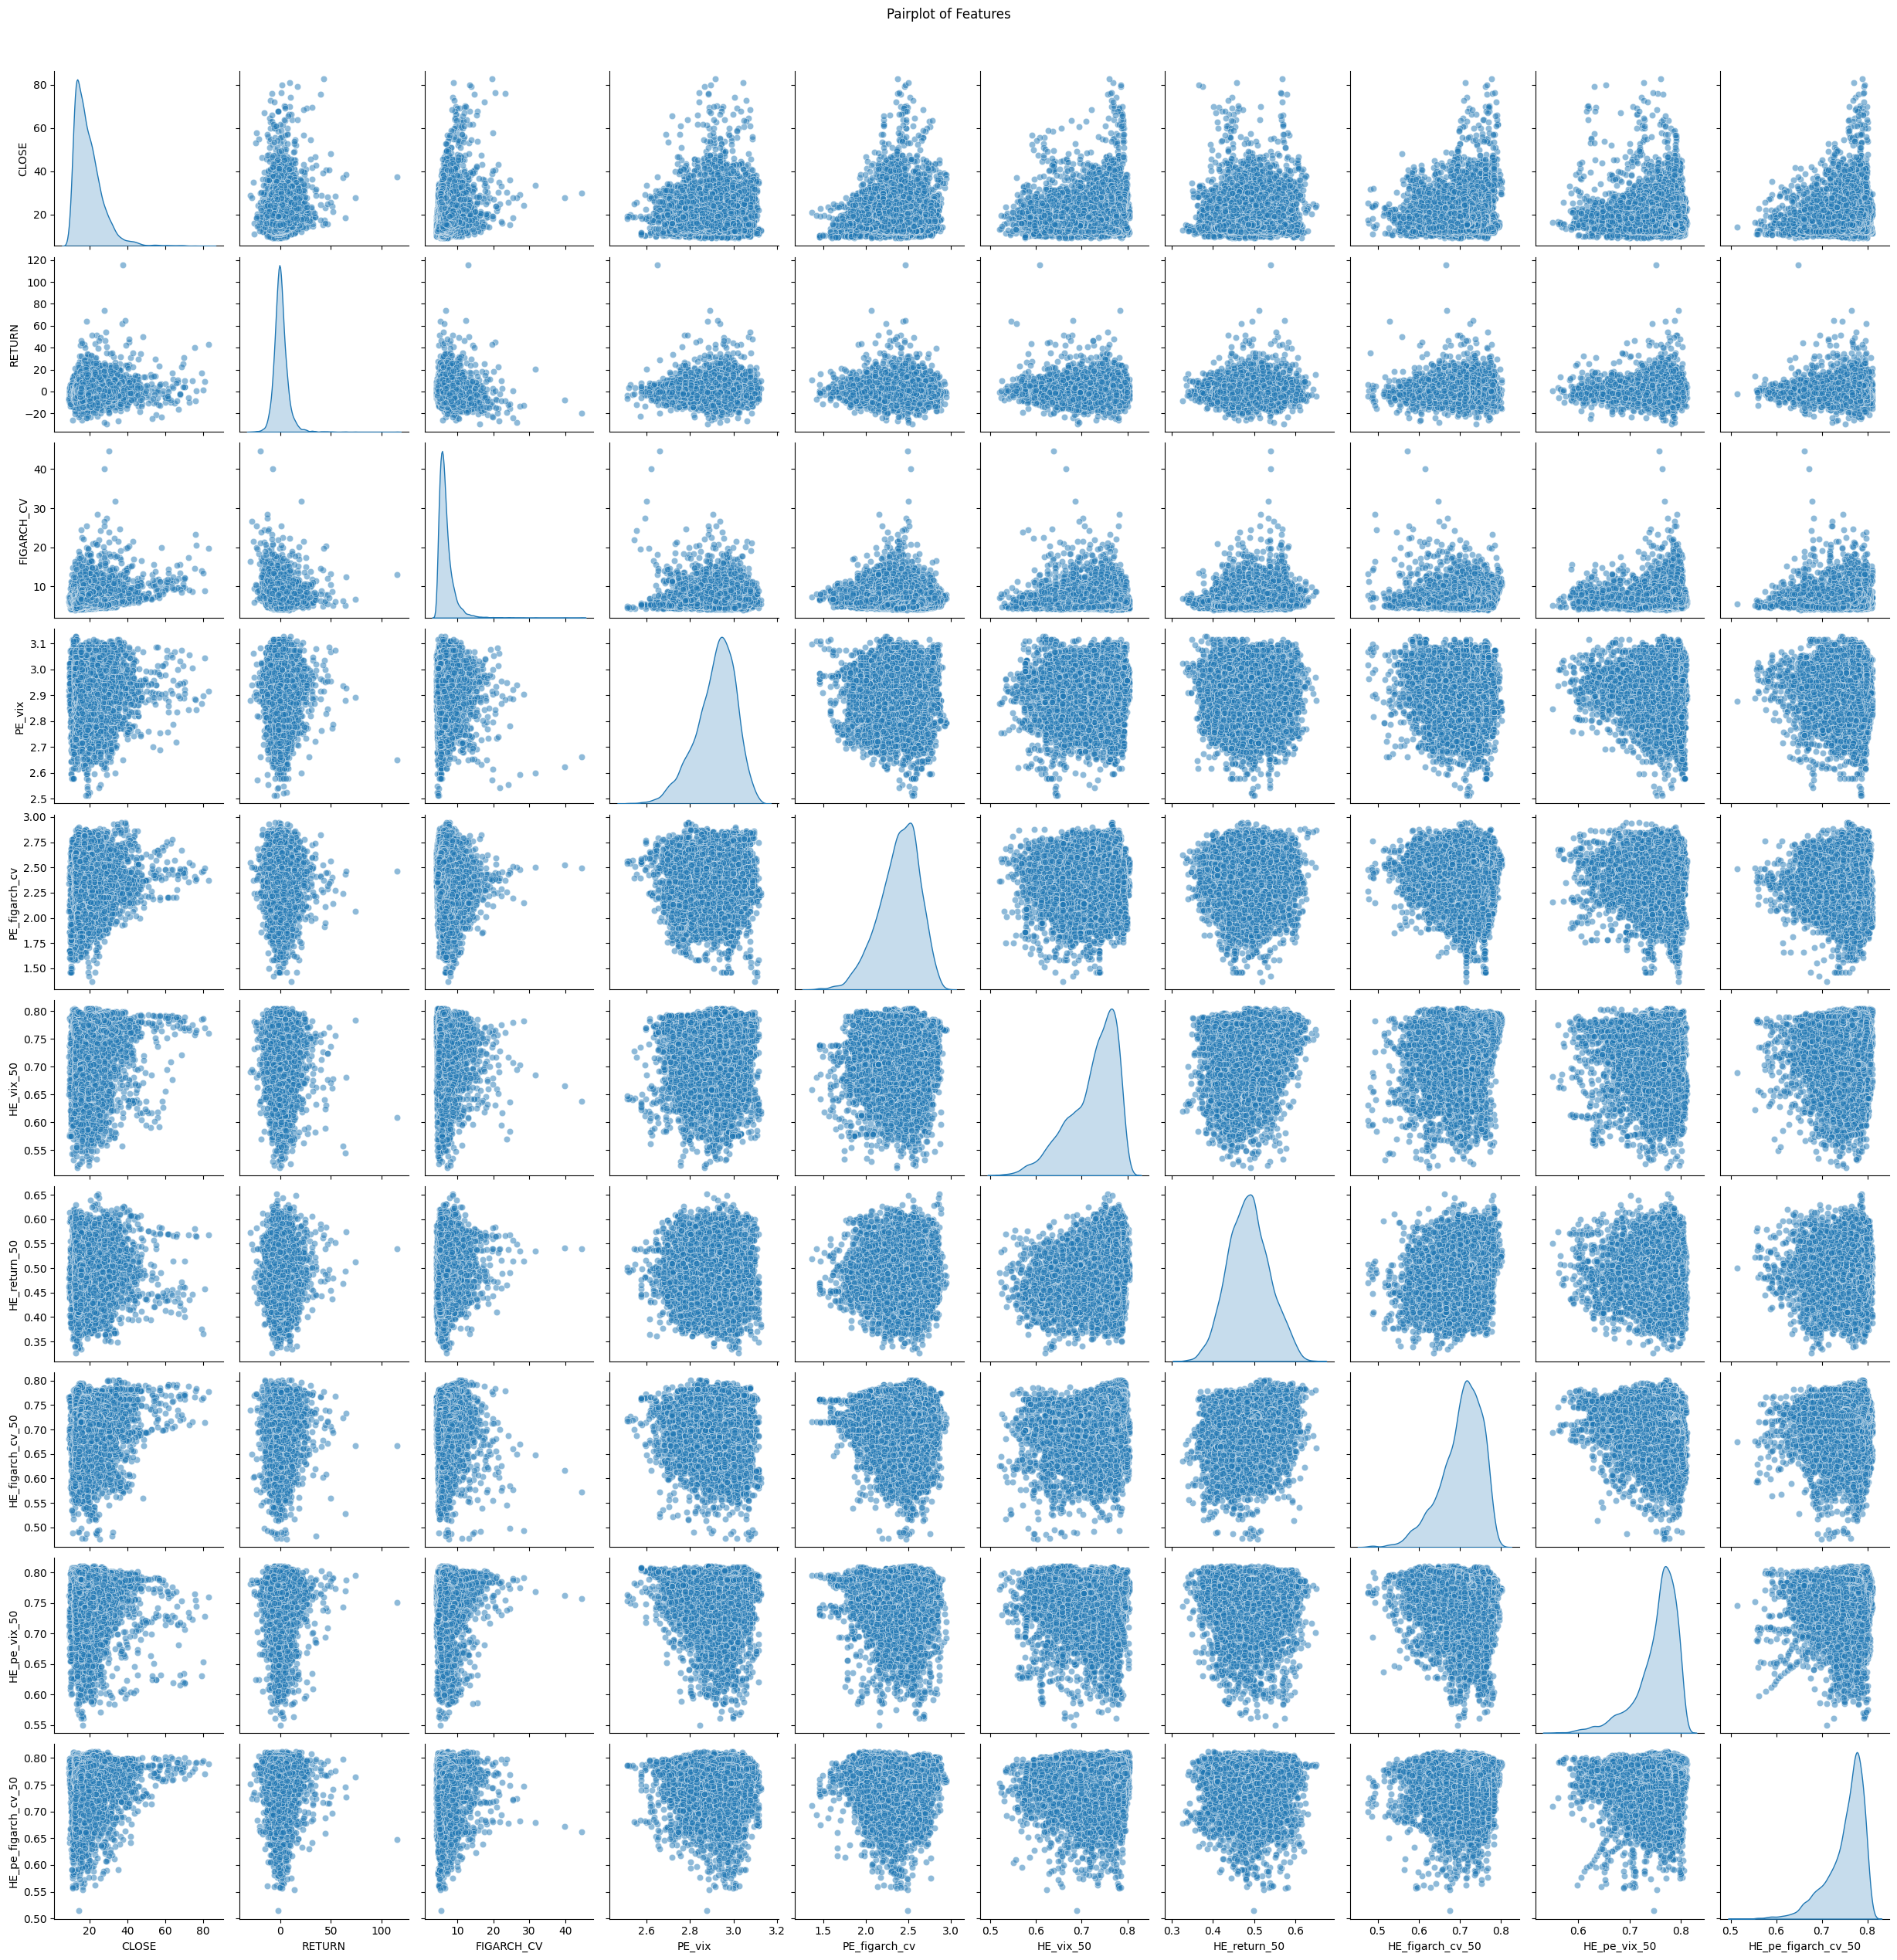

In [18]:
# -----------------------------------
# Cell 17: Pairplot of Key Features
# -----------------------------------

sns.pairplot(
    df[features].dropna(),
    kind='scatter',
    diag_kind='kde',
    plot_kws={'alpha':0.5}
)
plt.suptitle('Pairplot of Features', y=1.02)
plt.show()


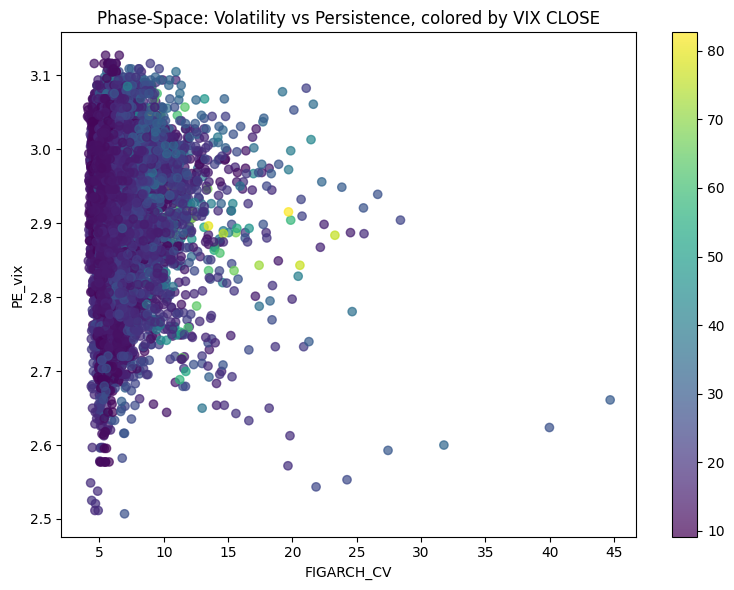

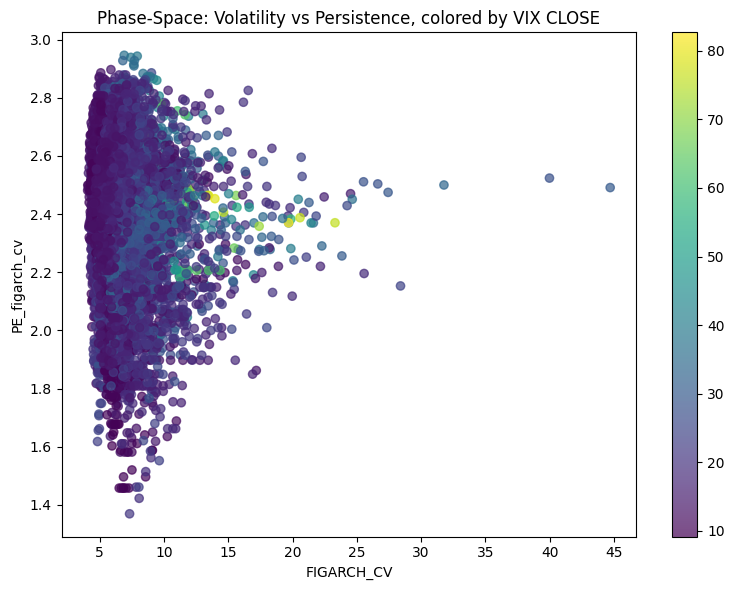

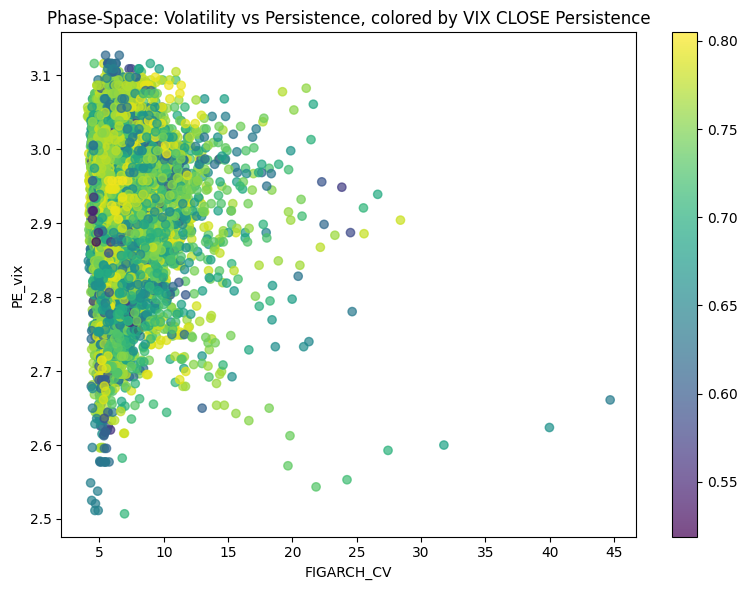

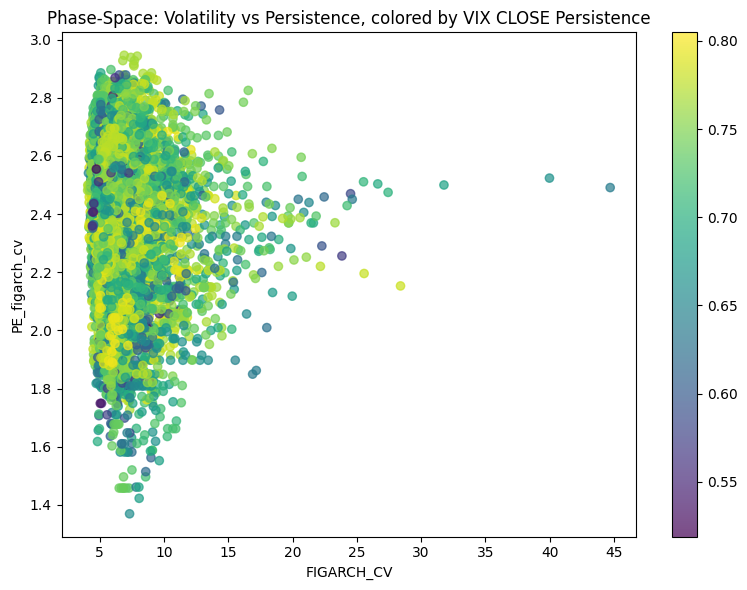

In [31]:
# -----------------------------------
# Cell 18: Phase-Space CLOSE Scatter (Magnitude vs Chaos)
# -----------------------------------

# Magnitude vs Chaos (CLOSE) 
plt.figure(figsize=(8,6))
sc = plt.scatter(
    df['FIGARCH_CV'], df['PE_vix'],
    c=df['CLOSE'], cmap='viridis', alpha=0.7
)
plt.colorbar(sc)
plt.xlabel('FIGARCH_CV')
plt.ylabel('PE_vix')
plt.title('Phase-Space: Volatility vs Persistence, colored by VIX CLOSE')
plt.tight_layout()
plt.show()

# Magnitude vs Chaos (CLOSE) 
plt.figure(figsize=(8,6))
sc = plt.scatter(
    df['FIGARCH_CV'], df['PE_figarch_cv'],
    c=df['CLOSE'], cmap='viridis', alpha=0.7
)
plt.colorbar(sc)
plt.xlabel('FIGARCH_CV')
plt.ylabel('PE_figarch_cv')
plt.title('Phase-Space: Volatility vs Persistence, colored by VIX CLOSE')
plt.tight_layout()
plt.show()

# Magnitude vs Chaos (CLOSE Persistence) 
plt.figure(figsize=(8,6))
sc = plt.scatter(
    df['FIGARCH_CV'], df['PE_vix'],
    c=df['HE_vix_50'], cmap='viridis', alpha=0.7
)
plt.colorbar(sc)
plt.xlabel('FIGARCH_CV')
plt.ylabel('PE_vix')
plt.title('Phase-Space: Volatility vs Persistence, colored by VIX CLOSE Persistence')
plt.tight_layout()
plt.show()

# Magnitude vs Chaos (CLOSE Persistence) 
plt.figure(figsize=(8,6))
sc = plt.scatter(
    df['FIGARCH_CV'], df['PE_figarch_cv'],
    c=df['HE_vix_50'], cmap='viridis', alpha=0.7
)
plt.colorbar(sc)
plt.xlabel('FIGARCH_CV')
plt.ylabel('PE_figarch_cv')
plt.title('Phase-Space: Volatility vs Persistence, colored by VIX CLOSE Persistence')
plt.tight_layout()
plt.show()


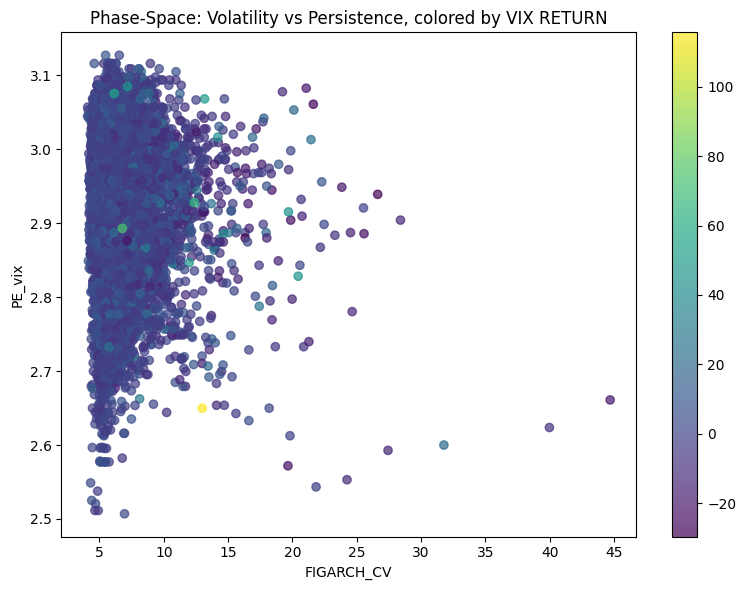

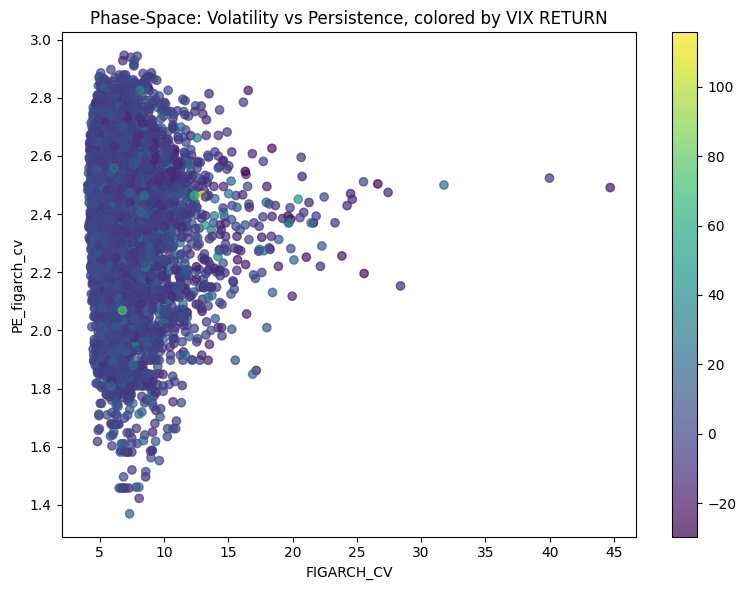

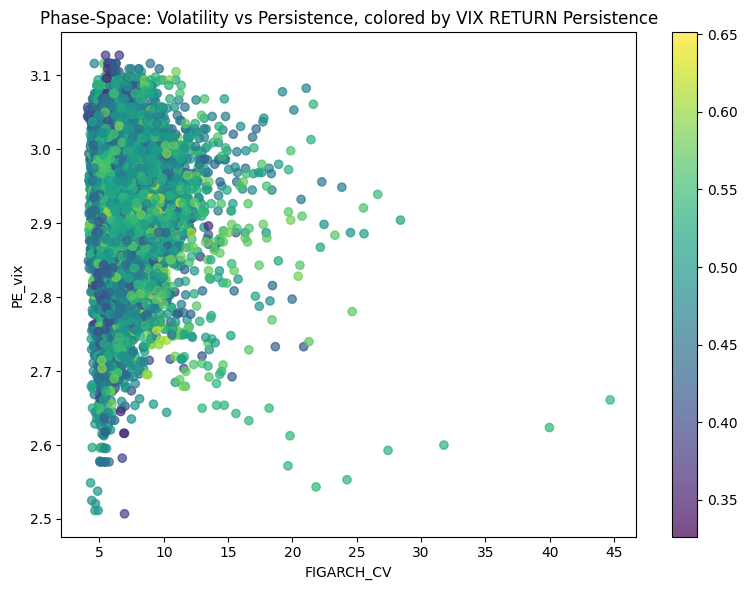

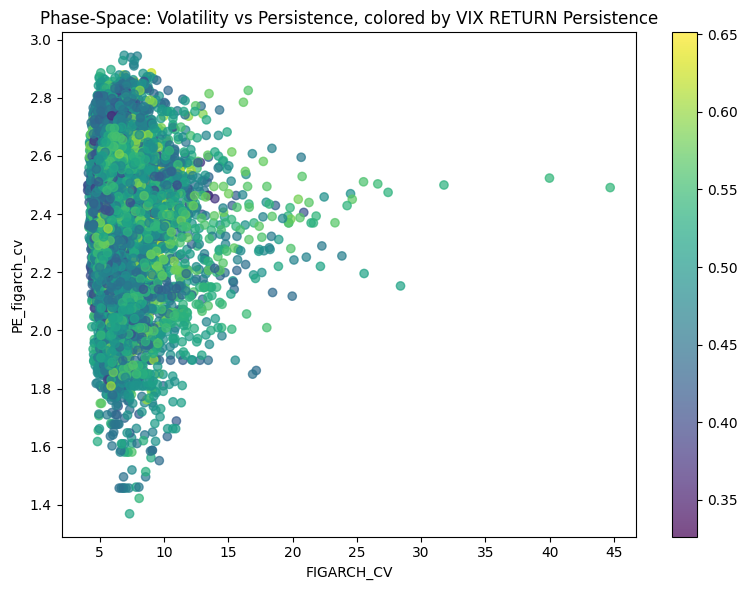

In [32]:
# -----------------------------------
# Cell 19: Phase-Space RETURN Scatter (Magnitude vs Chaos)
# -----------------------------------

# Magnitude vs Chaos (RETURN) 
plt.figure(figsize=(8,6))
sc = plt.scatter(
    df['FIGARCH_CV'], df['PE_vix'],
    c=df['RETURN'], cmap='viridis', alpha=0.7
)
plt.colorbar(sc)
plt.xlabel('FIGARCH_CV')
plt.ylabel('PE_vix')
plt.title('Phase-Space: Volatility vs Persistence, colored by VIX RETURN')
plt.tight_layout()
plt.show()

# Magnitude vs Chaos (RETURN) 
plt.figure(figsize=(8,6))
sc = plt.scatter(
    df['FIGARCH_CV'], df['PE_figarch_cv'],
    c=df['RETURN'], cmap='viridis', alpha=0.7
)
plt.colorbar(sc)
plt.xlabel('FIGARCH_CV')
plt.ylabel('PE_figarch_cv')
plt.title('Phase-Space: Volatility vs Persistence, colored by VIX RETURN')
plt.tight_layout()
plt.show()

# Magnitude vs Chaos (RETURN Persistence) 
plt.figure(figsize=(8,6))
sc = plt.scatter(
    df['FIGARCH_CV'], df['PE_vix'],
    c=df['HE_return_50'], cmap='viridis', alpha=0.7
)
plt.colorbar(sc)
plt.xlabel('FIGARCH_CV')
plt.ylabel('PE_vix')
plt.title('Phase-Space: Volatility vs Persistence, colored by VIX RETURN Persistence')
plt.tight_layout()
plt.show()

# Magnitude vs Chaos (RETURN Persistence) 
plt.figure(figsize=(8,6))
sc = plt.scatter(
    df['FIGARCH_CV'], df['PE_figarch_cv'],
    c=df['HE_return_50'], cmap='viridis', alpha=0.7
)
plt.colorbar(sc)
plt.xlabel('FIGARCH_CV')
plt.ylabel('PE_figarch_cv')
plt.title('Phase-Space: Volatility vs Persistence, colored by VIX RETURN Persistence')
plt.tight_layout()
plt.show()


In [ ]:
# -----------------------------------
# Cell 19: Variance Inflation Factor (VIF) Test
# -----------------------------------

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select the six features
X = df[features].dropna()

# Add constant for VIF calculation
X_const = sm.add_constant(X)

vif_data = pd.DataFrame({
    'variable': X_const.columns,
    'VIF': [variance_inflation_factor(X_const.values, i)
            for i in range(X_const.shape[1])]
})
print(vif_data)


               variable          VIF
0                 const  2338.418139
1                 CLOSE     1.173722
2                RETURN     1.030069
3            FIGARCH_CV     1.151493
4                PE_vix     1.024951
5         PE_figarch_cv     1.058539
6             HE_vix_50     1.140825
7          HE_return_50     1.116216
8      HE_figarch_cv_50     1.121133
9          HE_pe_vix_50     1.034873
10  HE_pe_figarch_cv_50     1.021965


Quantile Binning

In [54]:
# -----------------------------------
# Cell 20: Quantile Bins & Feature Code
# -----------------------------------

# Define quantiles and labels
quantiles = [0, 0.2, 0.8, 1.0]
labels = [0, 1, 2]

# List of features to bin
features = [
    'CLOSE',
    'RETURN',
    'FIGARCH_CV',
    'PE_vix',
    'PE_figarch_cv',
    'HE_vix_50',
    'HE_return_50',
    'HE_figarch_cv_50',
    'HE_pe_vix_50',
    'HE_pe_figarch_cv_50'
]

# 1) Apply static 20/80 quantile binning
for col in features:
    df[f'{col}_BIN'] = pd.qcut(df[col], q=quantiles, labels=labels)

# 2) Build composite FEATURE_CODE from all bin columns
bin_cols = [f'{col}_BIN' for col in features]
df['FEATURE_CODE'] = df[bin_cols].astype(str).agg('_'.join, axis=1)

# 3) Drop any row that has a NaN in any of the new BIN columns or FEATURE_CODE
df.dropna(subset=bin_cols + ['FEATURE_CODE'], inplace=True)

# 4) Inspect the first few rows
print(df[bin_cols + ['FEATURE_CODE']].tail())


           CLOSE_BIN RETURN_BIN FIGARCH_CV_BIN PE_vix_BIN PE_figarch_cv_BIN  \
DATE                                                                          
2025-03-17         1          0              2          1                 0   
2025-03-18         1          2              2          1                 0   
2025-03-19         1          0              2          1                 0   
2025-03-20         1          1              2          1                 0   
2025-03-21         1          1              2          1                 0   

           HE_vix_50_BIN HE_return_50_BIN HE_figarch_cv_50_BIN  \
DATE                                                             
2025-03-17             1                1                    1   
2025-03-18             1                1                    1   
2025-03-19             2                2                    1   
2025-03-20             2                2                    1   
2025-03-21             2                2         

LSTM

In [79]:
# -----------------------------------
# Cell 21: Import 
# -----------------------------------

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report

from keras.utils import to_categorical       
from keras.models import Sequential, Model   
from keras.layers import LSTM, Dense, Input, Concatenate

In [76]:
# -----------------------------------
# Cell 21: Define Features, Targets & Look-Back Sequences
# -----------------------------------
import numpy as np

# 1) look-back length
L = 20

# 2) feature sets for each model
features_model1 = ['CLOSE', 'RETURN']
features_model2 = features.copy()   # raw features from Cell 20
features_model3 = bin_cols.copy()   # binned features from Cell 20

# 3) define targets
targets = ['CLOSE', 'RETURN', 'FIGARCH_CV', 'PE_vix']

# 4) sanity check inputs
print("Features Model1:", features_model1)
print("Features Model2:", features_model2)
print("Features Model3:", features_model3)
print("Targets:", targets)

# 5) helper to build sequences
def make_sequences(df, feat_cols, target, lookback=L):
    X, y = [], []
    for i in range(lookback, len(df)):
        X.append(df[feat_cols].iloc[i-lookback:i].values)
        y.append(df[target].iloc[i])
    return np.array(X), np.array(y)

# 6) build sequences for each model & each target
# Model 1
X1_close,      y1_close      = make_sequences(df, features_model1, 'CLOSE')
X1_return,     y1_return     = make_sequences(df, features_model1, 'RETURN')
X1_figarch_cv, y1_figarch_cv = make_sequences(df, features_model1, 'FIGARCH_CV')
X1_pe_vix,     y1_pe_vix     = make_sequences(df, features_model1, 'PE_vix')

# Model 2
X2_close,      y2_close      = make_sequences(df, features_model2, 'CLOSE')
X2_return,     y2_return     = make_sequences(df, features_model2, 'RETURN')
X2_figarch_cv, y2_figarch_cv = make_sequences(df, features_model2, 'FIGARCH_CV')
X2_pe_vix,     y2_pe_vix     = make_sequences(df, features_model2, 'PE_vix')

# Model 3
X3_close,      y3_close      = make_sequences(df, features_model3, 'CLOSE')
X3_return,     y3_return     = make_sequences(df, features_model3, 'RETURN')
X3_figarch_cv, y3_figarch_cv = make_sequences(df, features_model3, 'FIGARCH_CV')
X3_pe_vix,     y3_pe_vix     = make_sequences(df, features_model3, 'PE_vix')

# 7) sanity check shapes
print("\nSanity check shapes:")
for name, X, y in [
    ('M1_CLOSE', X1_close, y1_close),
    ('M1_RETURN', X1_return, y1_return),
    ('M1_FCV', X1_figarch_cv, y1_figarch_cv),
    ('M1_PEV', X1_pe_vix, y1_pe_vix),
    ('M2_CLOSE', X2_close, y2_close),
    ('M2_RETURN', X2_return, y2_return),
    ('M2_FCV', X2_figarch_cv, y2_figarch_cv),
    ('M2_PEV', X2_pe_vix, y2_pe_vix),
    ('M3_CLOSE', X3_close, y3_close),
    ('M3_RETURN', X3_return, y3_return),
    ('M3_FCV', X3_figarch_cv, y3_figarch_cv),
    ('M3_PEV', X3_pe_vix, y3_pe_vix),
]:
    print(f"{name}: X={X.shape}, y={y.shape}")


Features Model1: ['CLOSE', 'RETURN']
Features Model2: ['CLOSE', 'RETURN', 'FIGARCH_CV', 'PE_vix', 'PE_figarch_cv', 'HE_vix_50', 'HE_return_50', 'HE_figarch_cv_50', 'HE_pe_vix_50', 'HE_pe_figarch_cv_50']
Features Model3: ['CLOSE_BIN', 'RETURN_BIN', 'FIGARCH_CV_BIN', 'PE_vix_BIN', 'PE_figarch_cv_BIN', 'HE_vix_50_BIN', 'HE_return_50_BIN', 'HE_figarch_cv_50_BIN', 'HE_pe_vix_50_BIN', 'HE_pe_figarch_cv_50_BIN']
Targets: ['CLOSE', 'RETURN', 'FIGARCH_CV', 'PE_vix']

Sanity check shapes:
M1_CLOSE: X=(8831, 20, 2), y=(8831,)
M1_RETURN: X=(8831, 20, 2), y=(8831,)
M1_FCV: X=(8831, 20, 2), y=(8831,)
M1_PEV: X=(8831, 20, 2), y=(8831,)
M2_CLOSE: X=(8831, 20, 10), y=(8831,)
M2_RETURN: X=(8831, 20, 10), y=(8831,)
M2_FCV: X=(8831, 20, 10), y=(8831,)
M2_PEV: X=(8831, 20, 10), y=(8831,)
M3_CLOSE: X=(8831, 20, 10), y=(8831,)
M3_RETURN: X=(8831, 20, 10), y=(8831,)
M3_FCV: X=(8831, 20, 10), y=(8831,)
M3_PEV: X=(8831, 20, 10), y=(8831,)


In [80]:
# -----------------------------------
# Cell 22: Train/Test, Model Training & Predictions (4 targets) – Store Results & ANOVA
# -----------------------------------

# common 80/20 split index
split = int(0.8 * X1_close.shape[0])

# helper to build a simple LSTM→Dense regressor (unchanged)
def build_lstm_regressor(n_feats):
    model = Sequential([
        LSTM(32, input_shape=(L, n_feats)),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# assemble all (X, y, label) tuples
runs = [
    (X1_close,      y1_close,      'Model1—CLOSE'),
    (X1_return,     y1_return,     'Model1—RETURN'),
    (X1_figarch_cv, y1_figarch_cv, 'Model1—FIGARCH_CV'),
    (X1_pe_vix,     y1_pe_vix,     'Model1—PE_vix'),
    (X2_close,      y2_close,      'Model2—CLOSE'),
    (X2_return,     y2_return,     'Model2—RETURN'),
    (X2_figarch_cv, y2_figarch_cv, 'Model2—FIGARCH_CV'),
    (X2_pe_vix,     y2_pe_vix,     'Model2—PE_vix'),
    (X3_close,      y3_close,      'Model3—CLOSE'),
    (X3_return,     y3_return,     'Model3—RETURN'),
    (X3_figarch_cv, y3_figarch_cv, 'Model3—FIGARCH_CV'),
    (X3_pe_vix,     y3_pe_vix,     'Model3—PE_vix'),
]

# container for all metrics
results = []

for X, y, label in runs:
    # ensure numeric dtype
    X = X.astype('float32')
    y = y.astype('float32')
    
    # split
    X_tr, X_te = X[:split], X[split:]
    y_tr, y_te = y[:split], y[split:]
    
    # train
    model = build_lstm_regressor(X.shape[2])
    print(f"\n=== Training {label} ===")
    model.fit(
        X_tr, y_tr,
        validation_data=(X_te, y_te),
        epochs=30, batch_size=32, verbose=1
    )
    
    # predict
    y_pred = model.predict(X_te)
    
    # core metrics
    mse = mean_squared_error(y_te, y_pred)
    mae = mean_absolute_error(y_te, y_pred)
    r2  = r2_score(y_te, y_pred)
    
    # ANOVA components
    ss_res = np.sum((y_te - y_pred.flatten())**2)
    ss_tot = np.sum((y_te - y_te.mean())**2)
    ss_reg = ss_tot - ss_res
    df_reg = 1
    df_res = len(y_te) - 2
    ms_reg = ss_reg / df_reg
    ms_res = ss_res / df_res
    f_stat = ms_reg / ms_res
    
    # store everything
    results.append({
        'label':  label,
        'mse':    mse,
        'mae':    mae,
        'r2':     r2,
        'ss_reg': ss_reg,
        'ss_res': ss_res,
        'ss_tot': ss_tot,
        'df_reg': df_reg,
        'df_res': df_res,
        'ms_reg': ms_reg,
        'ms_res': ms_res,
        'f_stat': f_stat
    })

# now `results` holds a dict of metrics+ANOVA for each run



=== Training Model1—CLOSE ===
Epoch 1/30


c:\Users\npwol\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 310.5136 - mae: 15.6070 - val_loss: 117.2620 - val_mae: 7.6558
Epoch 2/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 90.2842 - mae: 6.3658 - val_loss: 64.1226 - val_mae: 5.0230
Epoch 3/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 55.1026 - mae: 4.6488 - val_loss: 40.4563 - val_mae: 2.9832
Epoch 4/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 35.4428 - mae: 2.7460 - val_loss: 29.6206 - val_mae: 2.2905
Epoch 5/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 28.5059 - mae: 2.1551 - val_loss: 23.5992 - val_mae: 1.9253
Epoch 6/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 18.2535 - mae: 1.7301 - val_loss: 20.0062 - val_mae: 1.7150
Epoch 7/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 15.7685 - mae: 1.6084 - val_loss: 17.5827 - val_mae: 1.5941
Epoch 8/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 15.5213 - mae: 1.4911 - val_loss: 15.7764 - val_mae: 1.5308
Epoch 9/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/s

c:\Users\npwol\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 42.6832 - mae: 4.5854 - val_loss: 67.4086 - val_mae: 5.4567
Epoch 2/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 51.1913 - mae: 4.6928 - val_loss: 66.9784 - val_mae: 5.5573
Epoch 3/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 46.6333 - mae: 4.6705 - val_loss: 67.4789 - val_mae: 5.4394
Epoch 4/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 42.5487 - mae: 4.5963 - val_loss: 67.3170 - val_mae: 5.4634
Epoch 5/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 44.2346 - mae: 4.6122 - val_loss: 67.1930 - val_mae: 5.4669
Epoch 6/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 44.6077 - mae: 4.6397 - val_loss: 67.0809 - val_mae: 5.5010
Epoch 7/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 44.4887 - mae: 4.7077 - val_loss: 67.0669 - val_mae: 5.5930
Epoch 8/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 43.3336 - mae: 4.5870 - val_loss: 67.4271 - val_mae: 5.4446
Epoch 9/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

...

221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 47.7635 - mae: 4.7744 - val_loss: 67.5394 - val_mae: 5.5230
Epoch 2/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 43.2138 - mae: 4.5961 - val_loss: 67.4439 - val_mae: 5.5175
Epoch 3/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 45.0537 - mae: 4.7060 - val_loss: 67.2968 - val_mae: 5.5547
Epoch 4/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 50.3397 - mae: 4.7202 - val_loss: 67.2780 - val_mae: 5.5380
Epoch 5/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 44.7699 - mae: 4.6856 - val_loss: 67.2421 - val_mae: 5.5721
Epoch 6/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 44.8656 - mae: 4.6664 - val_loss: 67.3536 - val_mae: 5.4892
Epoch 7/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 50.7852 - mae: 4.7308 - val_loss: 67.2674 - val_mae: 5.5380
Epoch 8/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 46.7894 - mae: 4.7256 - val_loss: 67.2768 - val_mae: 5.5533
Epoch 9/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

c:\Users\npwol\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 18.4116 - mae: 3.2616 - val_loss: 6.8133 - val_mae: 1.4719
Epoch 2/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.9003 - mae: 0.9541 - val_loss: 5.2841 - val_mae: 1.1304
Epoch 3/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.5092 - mae: 0.8029 - val_loss: 4.4051 - val_mae: 1.0547
Epoch 4/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.2274 - mae: 0.7541 - val_loss: 4.1035 - val_mae: 1.0967
Epoch 5/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.7414 - mae: 0.7142 - val_loss: 4.0513 - val_mae: 1.0484
Epoch 6/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.6898 - mae: 0.7103 - val_loss: 3.9057 - val_mae: 1.0600
Epoch 7/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.1904 - mae: 0.7259 - val_loss: 3.9665 - val_mae: 1.0784
Epoch 8/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.7135 - mae: 0.6921 - val_loss: 4.0329 - val_mae: 1.1225
Epoch 9/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.7548

c:\Users\npwol\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.0893 - mae: 0.6290 - val_loss: 0.0060 - val_mae: 0.0610
Epoch 2/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0054 - mae: 0.0567 - val_loss: 0.0033 - val_mae: 0.0453
Epoch 3/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0037 - mae: 0.0472 - val_loss: 0.0026 - val_mae: 0.0409
Epoch 4/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0029 - mae: 0.0424 - val_loss: 0.0023 - val_mae: 0.0390
Epoch 5/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0026 - mae: 0.0399 - val_loss: 0.0024 - val_mae: 0.0401
Epoch 6/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0025 - mae: 0.0395 - val_loss: 0.0021 - val_mae: 0.0371
Epoch 7/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0023 - mae: 0.0382 - val_loss: 0.0020 - val_mae: 0.0365
Epoch 8/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0023 - mae: 0.0375 - val_loss: 0.0021 - val_mae: 0.0373
Epoch 9/30
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0023 

R² Scores by Model and Target:
  Model1—CLOSE: 0.9149
  Model1—RETURN: -0.0086
  Model1—FIGARCH_CV: 0.9267
  Model1—PE_vix: -0.1559
  Model2—CLOSE: 0.9169
  Model2—RETURN: -0.0028
  Model2—FIGARCH_CV: 0.9944
  Model2—PE_vix: 0.8127
  Model3—CLOSE: 0.5051
  Model3—RETURN: -0.0199
  Model3—FIGARCH_CV: 0.4414
  Model3—PE_vix: 0.7183


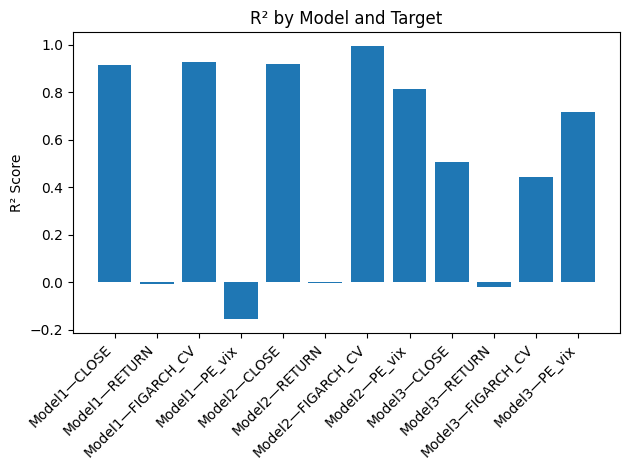

In [82]:
# -----------------------------------
# Cell 23: R² Scores by Model & Target
# -----------------------------------

# 1) extract labels and R² from your stored results
labels   = [r['label'] for r in results]
r2_scores = [r['r2']    for r in results]

# 2) print out each R²
print("R² Scores by Model and Target:")
for lbl, score in zip(labels, r2_scores):
    print(f"  {lbl}: {score:.4f}")

# 3) bar chart of R²
x = np.arange(len(labels))
plt.figure()
plt.bar(x, r2_scores)
plt.xticks(x, labels, rotation=45, ha='right')
plt.ylabel('R² Score')
plt.title('R² by Model and Target')
plt.tight_layout()
plt.show()


In [67]:
# -----------------------------------
# Cell 21: Prepare Data for LSTM Models
# -----------------------------------

# Scale CLOSE to [0,1]
scaler = MinMaxScaler()
df['CLOSE_SCALED'] = scaler.fit_transform(df[['CLOSE']])

# Encode FEATURE_CODE as integers
le = LabelEncoder()
df['CODE_INT'] = le.fit_transform(df['FEATURE_CODE'])

# Build look-back sequences of length L
L = 20
X_close, X_code, y = [], [], []
for i in range(L, len(df)):
    X_close.append(df['CLOSE_SCALED'].iloc[i-L:i].values)
    X_code.append(df['CODE_INT'].iloc[i-1])  
    y.append(df['CLOSE_SCALED'].iloc[i])      

X_close = np.array(X_close).reshape(-1, L, 1)
X_code  = np.array(X_code)
y       = np.array(y)

# One-hot encode the regime codes for Model 2
X_code_ohe = to_categorical(X_code, num_classes=len(le.classes_))

# Train/test split (80/20)
split = int(0.8 * len(y))
X1_train, X1_test = X_close[:split],     X_close[split:]
X2_train, X2_test = X_code_ohe[:split],  X_code_ohe[split:]
y_train,    y_test    = y[:split],       y[split:]

print("Prepared shapes:")
print("  X_close:", X_close.shape)
print("  X_code_ohe:", X_code_ohe.shape)
print("  y:", y.shape)


Prepared shapes:
  X_close: (8831, 20, 1)
  X_code_ohe: (8831, 4149)
  y: (8831,)


In [68]:
# -----------------------------------
# Cell 22: Model 1 — LSTM on CLOSE Only
# -----------------------------------

model1 = Sequential([
    LSTM(32, input_shape=(L,1)),
    Dense(1, activation='linear')
])
model1.compile(optimizer='adam', loss='mse', metrics=['mae'])

history1 = model1.fit(
    X1_train, y_train,
    validation_data=(X1_test, y_test),
    epochs=20, batch_size=32, verbose=1
)

Epoch 1/20


c:\Users\npwol\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0034 - mae: 0.0354 - val_loss: 0.0017 - val_mae: 0.0242
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.4266e-04 - mae: 0.0192 - val_loss: 0.0013 - val_mae: 0.0227
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.2739e-04 - mae: 0.0186 - val_loss: 0.0011 - val_mae: 0.0205
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6506e-04 - mae: 0.0173 - val_loss: 0.0011 - val_mae: 0.0214
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.8330e-04 - mae: 0.0168 - val_loss: 9.6090e-04 - val_mae: 0.0185
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.0612e-04 - mae: 0.0159 - val_loss: 9.8289e-04 - val_mae: 0.0193
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.3225e-04 - mae: 0.0150 - val_loss: 8.3296e-04 - val_mae: 0.0172
Epoch 8/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.5870e-04 - mae: 0.0140 - val_loss: 7.9626e-04 - val_mae: 0.0173
Epoch 9/20
221/221 ━━━━

In [69]:
# -----------------------------------
# Cell 23: Model 2 — Hybrid LSTM + Regime Code
# -----------------------------------

# Close‐sequence branch
input_close = Input(shape=(L,1), name='close_input')
x = LSTM(32)(input_close)

# Regime‐code branch (one‐hot vector)
input_code = Input(shape=(len(le.classes_),), name='code_input')
y_c = Dense(16, activation='relu')(input_code)

# Combine & predict
combined = Concatenate()([x, y_c])
output   = Dense(1, activation='linear')(combined)

model2 = Model([input_close, input_code], output)
model2.compile(optimizer='adam', loss='mse', metrics=['mae'])

history2 = model2.fit(
    [X1_train, X2_train], y_train,
    validation_data=([X1_test, X2_test], y_test),
    epochs=20, batch_size=32, verbose=1
)

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0053 - mae: 0.0443 - val_loss: 0.0021 - val_mae: 0.0277
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.9773e-04 - mae: 0.0187 - val_loss: 0.0016 - val_mae: 0.0258
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.2812e-04 - mae: 0.0144 - val_loss: 0.0015 - val_mae: 0.0249
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.5719e-04 - mae: 0.0131 - val_loss: 0.0014 - val_mae: 0.0246
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.7286e-04 - mae: 0.0124 - val_loss: 0.0013 - val_mae: 0.0251
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.3520e-04 - mae: 0.0121 - val_loss: 0.0013 - val_mae: 0.0253
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.3746e-04 - mae: 0.0119 - val_loss: 0.0012 - val_mae: 0.0230
Epoch 8/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.7004e-04 - mae: 0.0106 - val_loss: 0.0012 - val_mae: 0.0230
Epoch 9/20
221/221 ━━━━━━━━━

In [70]:
# -----------------------------------
# Cell 24: Evaluate Regression Metrics
# -----------------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1) Predict next‐day scaled prices
yhat1_scaled = model1.predict(X1_test)
yhat2_scaled = model2.predict([X1_test, X2_test])

# 2) Invert scaling to get actual prices
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
yhat1_actual = scaler.inverse_transform(yhat1_scaled).flatten()
yhat2_actual = scaler.inverse_transform(yhat2_scaled).flatten()

# 3) Compute regression metrics
mse1 = mean_squared_error(y_test_actual, yhat1_actual)
mae1 = mean_absolute_error(y_test_actual, yhat1_actual)
mse2 = mean_squared_error(y_test_actual, yhat2_actual)
mae2 = mean_absolute_error(y_test_actual, yhat2_actual)

# 4) Print results
print("=== Model 1 (Close only) ===")
print(f"  MSE: {mse1:.6f}")
print(f"  MAE: {mae1:.6f}")

print("\n=== Model 2 (Close + Regime Code) ===")
print(f"  MSE: {mse2:.6f}")
print(f"  MAE: {mae2:.6f}")

# 5) (Optional) Quick peek at the first few predictions vs actual
for i in range(5):
    print(f"Day {i+1:>2}: Actual={y_test_actual[i]:.2f} | Model1={yhat1_actual[i]:.2f} | Model2={yhat2_actual[i]:.2f}")


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== Model 1 (Close only) ===
  MSE: 4.143509
  MAE: 1.247901

=== Model 2 (Close + Regime Code) ===
  MSE: 4.995199
  MAE: 1.462260
Day  1: Actual=17.41 | Model1=19.19 | Model2=19.86
Day  2: Actual=16.56 | Model1=18.13 | Model2=17.97
Day  3: Actual=15.25 | Model1=17.31 | Model2=18.91
Day  4: Actual=15.60 | Model1=16.16 | Model2=17.91
Day  5: Actual=15.96 | Model1=16.21 | Model2=16.74


In [ ]:
# -----------------------------
# Cell 21: 1-Step Markov Heatmap 
# -----------------------------

# 12.0 
def markov_transition_matrix(regime_series):
    seq = regime_series.dropna().values
    states = sorted(set(seq))
    T = pd.DataFrame(0, index=states, columns=states, dtype=float)
    for cur, nxt in zip(seq[:-1], seq[1:]):
        T.loc[cur, nxt] += 1
    return T.div(T.sum(axis=1), axis=0)


# 12.1 Drop any time‐step where at least one TV-bin is NaN
bin_cols = ['FIG_CV_ZS_TV_BIN','PE_ISO_ZS_TV_BIN','HE_100_ZS_TV_BIN']
valid = df[bin_cols].notna().all(axis=1)
df_clean = df.loc[valid].copy()

# 12.2 Recreate composite code on the filtered data
df_clean['FEATURE_CODE'] = (
    df_clean['FIG_CV_ZS_TV_BIN'].astype(int).astype(str) + '_' +
    df_clean['PE_ISO_ZS_TV_BIN'].astype(int).astype(str) + '_' +
    df_clean['HE_100_ZS_TV_BIN'].astype(int).astype(str)
)

# 12.3 Build the empirical transition probabilities
T = markov_transition_matrix(df_clean['FEATURE_CODE'])

# 12.4 Prepare custom annotations:
#      - If probability < 0.01 ⇒ blank
#      - Else ⇒ format to 2 decimals, lstrip the leading zero
annot = T.copy().applymap(
    lambda x: "" if x < 1e-2 else f"{x:.2f}".lstrip("0")
)

# 12.5 Plot heatmap with cleaned annotations
plt.figure(figsize=(10, 8))
sns.heatmap(
    T,
    annot=annot,       # our custom labels
    fmt="",            # no further formatting
    cmap="magma",
    cbar_kws={'label': 'P(next | current)'}
)
plt.title("1-Step Markov Transition")
plt.xlabel("Next Composite Code")
plt.ylabel("Current Composite Code")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# -----------------------------------
# Cell 22: Persistence Histogram of Diagonal Transition Probabilities
# -----------------------------------

# 1) Extract the diagonal (P(i→i)) — these are the persistence probs
#    This series tells us how “sticky” each composite regime is.
diag_probs = pd.Series(
    np.diag(T.values),     # <— use T, not trans_feat_clean
    index=T.index,
    name='persistence'
)


# 2) Sort regimes by their persistence probability (descending)
#    So the most‐persistent regimes appear first.
diag_sorted = diag_probs.sort_values(ascending=False)

# 3) Plot a bar chart of the sorted diagonal probabilities
#    This ordered histogram makes it easy to see which regimes are most stable.
plt.figure(figsize=(12, 6))
sns.barplot(
    x=diag_sorted.index,    # regimes on the x-axis
    y=diag_sorted.values,   # persistence on the y-axis
    palette="magma"
)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Composite Regime Code')
plt.ylabel('P(stay in same regime)')
plt.title('Regime Persistence (Diagonal Probabilities)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Signals

In [ ]:
# precompute thresholds (80th and 20th percentiles)
q80 = df['FIGARCH_CV'].quantile(0.8)
h20 = df['HE_figarch_cv_50'].quantile(0.2)

# regime signal: 1 = risk‐on, 0 = risk‐off
df['signal_regime'] = (
    (df['FIGARCH_CV'] <= q80) &
    (df['HE_figarch_cv_50'] >= h20)
).astype(int)

# your daily returns (e.g. SPX futures) in df['RET_SPX']
df['strategy_A'] = df['signal_regime'] * df['RET_SPX']

target_vol = 0.10  # 10% annualized
# convert FIGARCH_CV (daily volatility in % terms) to annual volatility
ann_vol = df['FIGARCH_CV'] * np.sqrt(252) / 100

df['alloc_voltarget'] = (target_vol / ann_vol).clip(0, 2)  # cap leverage at 2x
df['strategy_B'] = df['alloc_voltarget'] * df['RET_SPX']

# Compute running peak and drawdown of the cumulative strategy
df['cumeq'] = (1 + df['strategy_A']).cumprod()
df['running_max'] = df['cumeq'].cummax()
df['drawdown'] = (df['cumeq'] / df['running_max']) - 1

# When drawdown < -10%, force cash
df['safe_signal'] = (df['drawdown'] < -0.10).astype(int)
df['final_alloc'] = df['signal_regime'] * (1 - df['safe_signal'])

df['strategy_D'] = df['final_alloc'] * df['RET_SPX']




KeyError: 'RET_SPX'